Setting the environment

In [70]:
import pandas as pd
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import numpy as np

In [71]:
from textacy import preprocessing
from functools import partial

preproc = preprocessing.make_pipeline(
    #partial(preprocessing.replace.numbers, repl = ""),
    partial(preprocessing.replace.user_handles, repl = ""),
    partial(preprocessing.replace.emojis, repl = ""),
    partial(preprocessing.replace.urls, repl = ""),
    preprocessing.normalize.unicode,
    preprocessing.normalize.whitespace
)   

Importing and cleaning data

In [72]:
data_path = r"data/extended_essay-br.csv"
raw_data = pd.read_csv(data_path)
len(raw_data)

6577

Cleaning text

In [73]:
raw_data['clean_content'] = raw_data['essay'].astype(str).apply(preproc)

In [74]:
filtered_data = raw_data[
    (raw_data['clean_content'].notna()) &  
    (raw_data['clean_content'] != '') &    
    (raw_data['clean_content'].str.strip() != '')  &
    (raw_data['clean_content'].str.split().str.len() >= 10)
]
len(raw_data)

6577

Lemmatization

In [75]:
import spacy
nlp = spacy.load("pt_core_news_md", disable=["ner", "parser"])
filtered_data["lemmatized"] = [
    " ".join([token.lemma_ for token in doc])
    for doc in tqdm(nlp.pipe(filtered_data["clean_content"], batch_size=50), total=len(filtered_data), desc="Lemmatizing")
]
filtered_data.head()

Lemmatizing: 100%|██████████| 6567/6567 [01:58<00:00, 55.60it/s]


,prompt,title,essay,c1,c2,c3,c4,c5,score,clean_content,lemmatized
0,4,Comenta-se que o ex-presidente Lula,['Comenta-se que o ex presidente Lula ex-presi...,0,0,0,0,0,0,['Comenta-se que o ex presidente Lula ex-presi...,[ ' Comenta-se que o ex presidente Lula ex-pre...
1,6,"Amazonas, um bem de todos nós","['Amazonas, sem ela ele os dias do brasil Bras...",0,0,0,0,0,0,"['Amazonas, sem ela ele os dias do brasil Bras...","[ ' Amazonas , sem ela ele o dia de o Brasil B..."
2,42,Comprometimento Escolar e Individual,['Eu acredito que os dois são muito importante...,0,0,0,0,0,0,['Eu acredito que os dois são muito importante...,[ ' eu acreditar que o dois ser muito importan...
3,4,Assunto que repercute de forma constante,['Assunto que repercute de forma constante nos...,0,0,0,0,0,0,['Assunto que repercute de forma constante nos...,[ ' assunto que repercutir de forma constante ...
4,2,União entre o órgão público e a opinião pública,['O supremo tribunal federal Supremo Tribunal ...,0,0,0,0,0,0,['O supremo tribunal federal Supremo Tribunal ...,[ ' o Supremo tribunal federal Supremo Tribuna...


Initializing Bertopic

Embeddings

In [76]:
docs = filtered_data.lemmatized.to_list()
docs = [item for item in docs if str(item) != 'nan']
docs

['[ \' Comenta-se que o ex presidente Lula ex-presidente Lula , em o ano de 2016 , após o decisão de o Supremo Tribunal de o Justiça Federal , ser condenar a a o segundo instância e ir diante o seu acusação de o lava jato de Lava Jato . ainda mais que vários réu infrator de penalidade penalidade grave dever manter em o prisão . \' , \' em primeiro lugar lugar , com 726 mil preso , em o o Brasil ter terceiro grande população carcerário de o mundo , isto ser o gravidade de lotação em o qual muitas vez não possuir infraestrutura adequado para receber o condenado . \' , \' além de isso de isso , o desembargador desembargador , após analisar o sentença , em seguida quando manter mantiver o detido , tornar o cadeia um escola de o crime isso ser dificultar o processo de ressocialização de o criminoso . \' , \' Por fim fim , conforme o livro o politica " Política " , de Aristósteles , acreditar que o democracia e ética de o ser humano e o felicidade de o ser além de isso quando afligir o lei d

In [77]:
model_name = "ibm-granite/granite-embedding-278m-multilingual"
sentence_model = SentenceTransformer(model_name)

In [78]:
sentence_model.max_seq_length 

512

In [79]:
embeddings = sentence_model.encode(docs, show_progress_bar=True)
#np.save("topic_models/embeddings/portulan900m_embeddings.npy", embeddings)

Batches:   0%|          | 0/206 [00:00<?, ?it/s]

In [ ]:
#embeddings = np.load("topic_models/embeddings/portulan900m_embeddings.npy")

In [80]:
from sklearn.preprocessing import normalize

normalized_embeddings = normalize(embeddings, norm="l2", axis=1)

Dimensionality Reduction

In [82]:
from umap import UMAP
#from cuml.manifold import UMAP
#from bertopic.dimensionality import BaseDimensionalityReduction

class Dimensionality:
  """ Use this for pre-calculated reduced embeddings """
  def __init__(self, reduced_embeddings):
    self.reduced_embeddings = reduced_embeddings

  def fit(self, X):
    return self

  def transform(self, X):
    return self.reduced_embeddings

n_neighbors = 15
umap_model = UMAP(n_neighbors=n_neighbors, n_components=5, metric="cosine", random_state=42, unique=True, min_dist=0.0)
#empty_reduction_model = BaseDimensionalityReduction()

In [83]:
reduced_embeddings = umap_model.fit_transform(normalized_embeddings)
#np.save("topic_models/embeddings/portulan900m_cuml_reduced_embeddings.npy", reduced_embeddings)

In [13]:
reduced_embeddings = np.load("topic_models/embeddings/portulan900m_cuml_reduced_embeddings.npy")

Clustering

In [84]:
from hdbscan import HDBSCAN
#from cuml.cluster import HDBSCAN
from bertopic.cluster import BaseCluster

min_cluster_size = 50
hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', prediction_data=True, min_samples = 25)
clusters = hdbscan_model.fit(reduced_embeddings).labels_

Representation

In [85]:
from stop_words import get_stop_words

pt_stopwords = get_stop_words("portuguese")

In [87]:
import collections
from tqdm import tqdm
from sklearn.feature_extraction.text import CountVectorizer

# Extract vocab to be used in BERTopic
vocab = collections.Counter()
tokenizer = CountVectorizer().build_tokenizer()
for doc in tqdm(docs):
  vocab.update(tokenizer(doc))
vocab = [word for word, frequency in vocab.items() if frequency >= 15]

stopwords_vectorizer_model = CountVectorizer(stop_words=pt_stopwords, vocabulary=vocab)
#ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

100%|██████████| 6567/6567 [00:00<00:00, 7896.93it/s] 


In [88]:
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, LangChain
# from langchain.chains.question_answering import load_qa_chain
# from langchain_ollama.llms import OllamaLLM

# llm = OllamaLLM(model="llama3.3:70b-instruct-q3_K_M")

# chain = load_qa_chain(llm, chain_type="stuff")

representation_model = {
    "KeyBERT": KeyBERTInspired(),
    "MMR": MaximalMarginalRelevance(diversity=0.4),
    #"LLM": LangChain(chain, prompt="What are these documents about? Please give a single label. Do not add any comment or note.")
    }

Topic Modelling

In [89]:
topic_model = BERTopic(
    verbose=True,
    nr_topics="auto",
    umap_model=Dimensionality(reduced_embeddings),
    hdbscan_model = BaseCluster(),
    vectorizer_model=stopwords_vectorizer_model,
    embedding_model=sentence_model,
    representation_model=representation_model,
    calculate_probabilities=False,
    #ctfidf_model=ctfidf_model
)
topics, probs = topic_model.fit_transform(docs, embeddings, y = clusters)

2026-04-27 13:31:47,466 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-27 13:31:47,468 - BERTopic - Dimensionality - Completed ✓
2026-04-27 13:31:47,470 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-27 13:31:47,474 - BERTopic - Cluster - Completed ✓
2026-04-27 13:31:47,476 - BERTopic - Representation - Extracting topics from clusters using representation models.
c:\Users\fabio\miniforge3\envs\nlp\Lib\site-packages\bertopic\vectorizers\_ctfidf.py:82: RuntimeWarning:

divide by zero encountered in divide

2026-04-27 13:31:59,377 - BERTopic - Representation - Completed ✓
2026-04-27 13:31:59,378 - BERTopic - Topic reduction - Reducing number of topics
c:\Users\fabio\miniforge3\envs\nlp\Lib\site-packages\bertopic\vectorizers\_ctfidf.py:82: RuntimeWarning:

divide by zero encountered in divide

2026-04-27 13:32:08,364 - BERTopic - Topic reduction - Reduced number of topics from 52 to 35


Inspect the model

In [90]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,MMR,Representative_Docs
0,-1,755,-1_ser_ter_poder_estar,"[ser, ter, poder, estar, pessoa, dever, fazer,...","[social, sociedade, público, cidadão, sobre, s...","[ser, poder, dever, fazer, vida, grande, socie...","[[ ' o estado ser compor , em seu grande parte..."
1,0,839,0_ser_poder_lei_ter,"[ser, poder, lei, ter, país, brasileiro, autor...","[democracia, presídio, prisão, carcerário, cid...","[ser, poder, lei, brasileiro, autoridade, abus...",[[ ' atualmente estar em o país democrático on...
2,1,403,1_sexual_criança_gravidez_jovem,"[sexual, criança, gravidez, jovem, adolescente...","[sexual, educação, sexualidade, sexualmente, s...","[sexual, gravidez, adolescente, infantil, prec...",[[ ' o educação sexual ser muito importante pa...
3,2,398,2_rede_mental_social_cancelamento,"[rede, mental, social, cancelamento, ser, ódio...","[social, afetar, depressão, internet, sociedad...","[rede, mental, social, ódio, usuário, internet...",[[ ' São Tomás de Aquino defender que todo o p...
4,3,356,3_vacina_ciência_científico_doença,"[vacina, ciência, científico, doença, vacinaçã...","[ciência, científico, vacinação, vacinar, vaci...","[vacina, científico, doença, negacionismo, sar...",[[ ' Sabemos que o corona vírus ser um pandemi...
5,4,317,4_negro_indígena_índio_ser,"[negro, indígena, índio, ser, povo, direito, t...","[racismo, negro, racial, racista, preconceito,...","[negro, indígena, povo, direito, terra, branco...",[[ ' o questão de o negro em o Brasil ainda de...
6,5,280,5_preconceito_asiático_amarelo_transfobia,"[preconceito, asiático, amarelo, transfobia, s...","[preconceito, racismo, discriminação, asiático...","[preconceito, asiático, amarelo, transfobia, t...",[[ ' o preconceito ser um juízo que se manifes...
7,6,265,6_arma_porte_fogo_segurança,"[arma, porte, fogo, segurança, violência, cida...","[arma, armamento, homicídio, desarmamento, vio...","[arma, segurança, desarmamento, civil, posse, ...",[[ ' após o atentado em o boate gay em Orlando...
8,7,162,7_esporte_esportivo_prática_físico,"[esporte, esportivo, prática, físico, atleta, ...","[esporte, esportivo, esportista, atleta, exerc...","[esporte, esportivo, físico, atleta, atividade...","[[ ' ao longo de o ano , o prática esportivo v..."
9,8,160,8_agrotóxico_alimento_produto_uso,"[agrotóxico, alimento, produto, uso, agricultu...","[agrotóxico, agroquímico, pesticida, tóxico, a...","[agrotóxico, uso, agricultura, transgênico, pe...",[[ ' o agrotóxico ser substância químico utili...


In [109]:
topic_model.get_representative_docs(topic=0)

["[ ' atualmente estar em o país democrático onde o pessoa poder se eleger , ou ser escolher seu governante , com o voto . que ser o direito de todo , ser com ele que o pessoa se tornar cidadão , ter seu direito , e livre participação político em o população . ' , ' antigamente só o minoria ter o direito de votar , mas em o atualidade tudo mudar .Agora todo ter esse participação político . ela ser o que chamar de democrácia . o população poder participar de o política , e enpor o lei de iniciativa popular . ou ser , o pessoa apresentar um projeto de lei em o camara de o deputado , que ser assinar por cidadão , e esse assinatura ser distribuir por o ( pouco por 5 ) estado brasileiro . ser o forma de planejamento de o sociedade contra vários acontecimento em o vida , que atormentar o povo . ' , ' além de isso como , o combate o corrupção eleitoral , que ser o compra de voto , ( e ) o lei Daniella Perez , que tratar de crime com grande gravidade , de intenção de matar . por tanto dar o di

In [92]:
outliers_strategy = "c-tf-idf"
new_topics = topic_model.reduce_outliers(docs, topics, strategy=outliers_strategy, threshold=0.3)

from collections import Counter
new_topic_dict = dict(Counter(new_topics))
print('Num of outliers:', new_topic_dict[-1])


Num of outliers: 619


In [93]:
topic_model.update_topics(docs, topics=new_topics)
topic_model.get_topic_info().sort_values(by="Count", ascending=False)

2026-04-27 13:36:42,333 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


,Topic,Count,Name,Representation,KeyBERT,MMR,Representative_Docs
1,0,844,0_de_que_em_ser,"[de, que, em, ser, um, para, por, se, não, com]","[democracia, presídio, prisão, carcerário, cid...","[ser, poder, lei, brasileiro, autoridade, abus...",[[ ' atualmente estar em o país democrático on...
0,-1,619,-1_que_de_ser_um,"[que, de, ser, um, em, se, não, para, por, seu]","[social, sociedade, público, cidadão, sobre, s...","[ser, poder, dever, fazer, vida, grande, socie...","[[ ' o estado ser compor , em seu grande parte..."
3,2,430,2_rede_social_mental_de,"[rede, social, mental, de, em, que, ser, um, p...","[social, afetar, depressão, internet, sociedad...","[rede, mental, social, ódio, usuário, internet...",[[ ' São Tomás de Aquino defender que todo o p...
2,1,410,1_sexual_criança_de_gravidez,"[sexual, criança, de, gravidez, em, jovem, ser...","[sexual, educação, sexualidade, sexualmente, s...","[sexual, gravidez, adolescente, infantil, prec...",[[ ' o educação sexual ser muito importante pa...
4,3,361,3_vacina_ciência_de_científico,"[vacina, ciência, de, científico, em, doença, ...","[ciência, científico, vacinação, vacinar, vaci...","[vacina, científico, doença, negacionismo, sar...",[[ ' Sabemos que o corona vírus ser um pandemi...
5,4,321,4_negro_de_ser_indígena,"[negro, de, ser, indígena, em, que, índio, pov...","[racismo, negro, racial, racista, preconceito,...","[negro, indígena, povo, direito, terra, branco...",[[ ' o questão de o negro em o Brasil ainda de...
6,5,281,5_preconceito_de_asiático_ser,"[preconceito, de, asiático, ser, em, que, esse...","[preconceito, racismo, discriminação, asiático...","[preconceito, asiático, amarelo, transfobia, t...",[[ ' o preconceito ser um juízo que se manifes...
7,6,265,6_arma_porte_fogo_de,"[arma, porte, fogo, de, em, segurança, violênc...","[arma, armamento, homicídio, desarmamento, vio...","[arma, segurança, desarmamento, civil, posse, ...",[[ ' após o atentado em o boate gay em Orlando...
8,7,162,7_esporte_esportivo_prática_de,"[esporte, esportivo, prática, de, físico, ser,...","[esporte, esportivo, esportista, atleta, exerc...","[esporte, esportivo, físico, atleta, atividade...","[[ ' ao longo de o ano , o prática esportivo v..."
9,8,160,8_agrotóxico_alimento_produto_uso,"[agrotóxico, alimento, produto, uso, de, em, s...","[agrotóxico, agroquímico, pesticida, tóxico, a...","[agrotóxico, uso, agricultura, transgênico, pe...",[[ ' o agrotóxico ser substância químico utili...


In [94]:
topic_labels = topic_model.generate_topic_labels(nr_words=3, aspect="KeyBERT")
topic_model.set_topic_labels(topic_labels)

Save/Load the model

In [14]:
topic_model = BERTopic.load("topic_models/models/btm_1b34_20250606-152038", embedding_model=model_name)

In [ ]:
from datetime import datetime
import json
import uuid

timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
short_id = uuid.uuid4().hex[:4]

filename = f"btm_{short_id}_{timestamp}"

metadata = {
    "id": short_id,
    "timestamp": timestamp,
    "dataset": data_path,
    "embedding_model": model_name,
    "n_neighbors": n_neighbors,
    "umap_type": "cuml",
    "hdbscan_type": "cuml",
    "min_cluster_size": min_cluster_size,
    "model_path": filename,
    "preprocessing": {
        "duplicates": "included",
        "non-pt texts": "included",
        "short texts": "excluded",
        "cleaning": "included"
    },
    "outliers_strategy": "c-tf-idf"
}

with open(f"topic_models/models/{filename}_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

In [ ]:
topic_model.save(f"topic_models/models/{filename}", serialization="safetensors", save_ctfidf=True, save_embedding_model=sentence_model)

In [18]:
docs_topics = topic_model.get_document_info(docs)
#docs_topics.to_pickle(f"topic_models/models/{filename}.pkl")

Clustering similar topics

In [110]:
hierarchical_topics = topic_model.hierarchical_topics(docs)

100%|██████████| 33/33 [00:00<00:00, 119.06it/s]


In [111]:
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

In [ ]:
topics_to_merge = [[1, 2],
                   [3, 4]]
topic_model.merge_topics(docs, topics_to_merge)

In [112]:
topic_model.visualize_heatmap()

Topics Distribution

In [ ]:
topic_distr, topic_token_distr = topic_model.approximate_distribution(docs, window=8, stride=1, calculate_tokens=True)

100%|██████████| 7/7 [00:39<00:00,  5.58s/it]


In [114]:
topic_model.visualize_distribution(topic_distr[1])

In [115]:
docs[1]

"[ ' Amazonas , sem ela ele o dia de o Brasil Brasil estar contado , o presidente Jair Bolsonaro , dever contar . o presidente Jair Bolsonaro dever estar fazer algo para-lhe para mostrar para em o nós , brasileiro , mais eu em o verdade mas eu , em o verdade , achar ele dever estar brincar com o o nosso cara . ' , ' mas e ele nao mas ele não sentir o ar pesar de poluição e desmatamento , a o amazona ela desmatamento . o Amazonas ser importante para um parte de o planeta , ou bom ela bom , ele gerar oxigênio limpo e puro e puro . mas , com esse incêndio , muito estado de outro país vizinho estar sofrer com o umidade relativo de o ar , a o amazonas Amazonas e bem de o sociedade que se importar com o natureza e também com o planeta , mais mas um coisa ser certo logo esse incêndio ira ir ser controlar e apagar para o felicidade de o nacionalidade brasileiro ... ' _"

In [118]:
#topic_distr, topic_token_distr = topic_model.approximate_distribution(docs, calculate_tokens=True)
topic_model.visualize_approximate_distribution(docs[1], topic_token_distr[1])

Visualizations

In [119]:
topic_model.visualize_topics(custom_labels=True)

In [103]:
filtered_data["score_bin"] = pd.qcut(
    filtered_data["score"],
    5,
    labels=["Very low", "Low", "Medium", "High", "Very high"]
)

In [104]:
topics_per_channel = topic_model.topics_per_class(
    docs=docs, classes=filtered_data["score_bin"], global_tuning=False,
)

5it [00:01,  3.28it/s]


In [105]:
topic_model.visualize_topics_per_class(topics_per_channel, top_n_topics=15, custom_labels=True, normalize_frequency=False)
# difference in volumes
# difference in t distributions
# similarity in discourse

In [ ]:
#timestamps = filtered_data.date.to_list()
#topics_over_time = topic_model.topics_over_time(docs, timestamps, nr_bins=20, global_tuning=False)

NameError: name 'timestamps' is not defined

In [106]:
topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=25, normalize_frequency=True, custom_labels=True)

NameError: name 'topics_over_time' is not defined

In [107]:
umap_model_2d = UMAP(n_components=2, n_neighbors=15, random_state=42, metric="cosine", verbose=True)
reduced_embeddings_2d = umap_model_2d.fit_transform(embeddings)

UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, random_state=42, verbose=True)
Mon Apr 27 13:45:22 2026 Construct fuzzy simplicial set
Mon Apr 27 13:45:22 2026 Finding Nearest Neighbors
Mon Apr 27 13:45:22 2026 Building RP forest with 9 trees
Mon Apr 27 13:45:22 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Mon Apr 27 13:45:23 2026 Finished Nearest Neighbor Search
Mon Apr 27 13:45:23 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon Apr 27 13:45:34 2026 Finished embedding


In [108]:
topic_model.visualize_documents(docs, reduced_embeddings=reduced_embeddings_2d, custom_labels=True, sample=0.01, hide_document_hover=False, topics=[0, 1,2,3,4,5,6,7,8,9,10])

In [57]:
from sklearn.manifold import TSNE

# Fit t-SNE
tsne_model_2d = TSNE(n_components=2, perplexity=30, random_state=42, metric="cosine", init="random")
reduced_embeddings_2d = tsne_model_2d.fit_transform(normalized_embeddings)

In [58]:
import itertools
import pandas as pd

# Define colors for the visualization to iterate over
colors = itertools.cycle(['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#ffffff', '#000000'])
color_key = {str(topic): next(colors) for topic in set(topic_model.topics_) if topic != -1}

# Prepare dataframe and ignore outliers
df = pd.DataFrame({"x": reduced_embeddings_2d[:, 0], "y": reduced_embeddings_2d[:, 1], "Topic": [str(t) for t in topic_model.topics_]})
df["Length"] = [len(doc) for doc in docs]
df = df.loc[df.Topic != "-1"]
df = df.loc[(df.y > -10) & (df.y < 10) & (df.x < 10) & (df.x > -10), :]
df["Topic"] = df["Topic"].astype("category")

# Get centroids of clusters
mean_df = df.groupby("Topic").mean().reset_index()
mean_df.Topic = mean_df.Topic.astype(int)
mean_df = mean_df.sort_values("Topic")

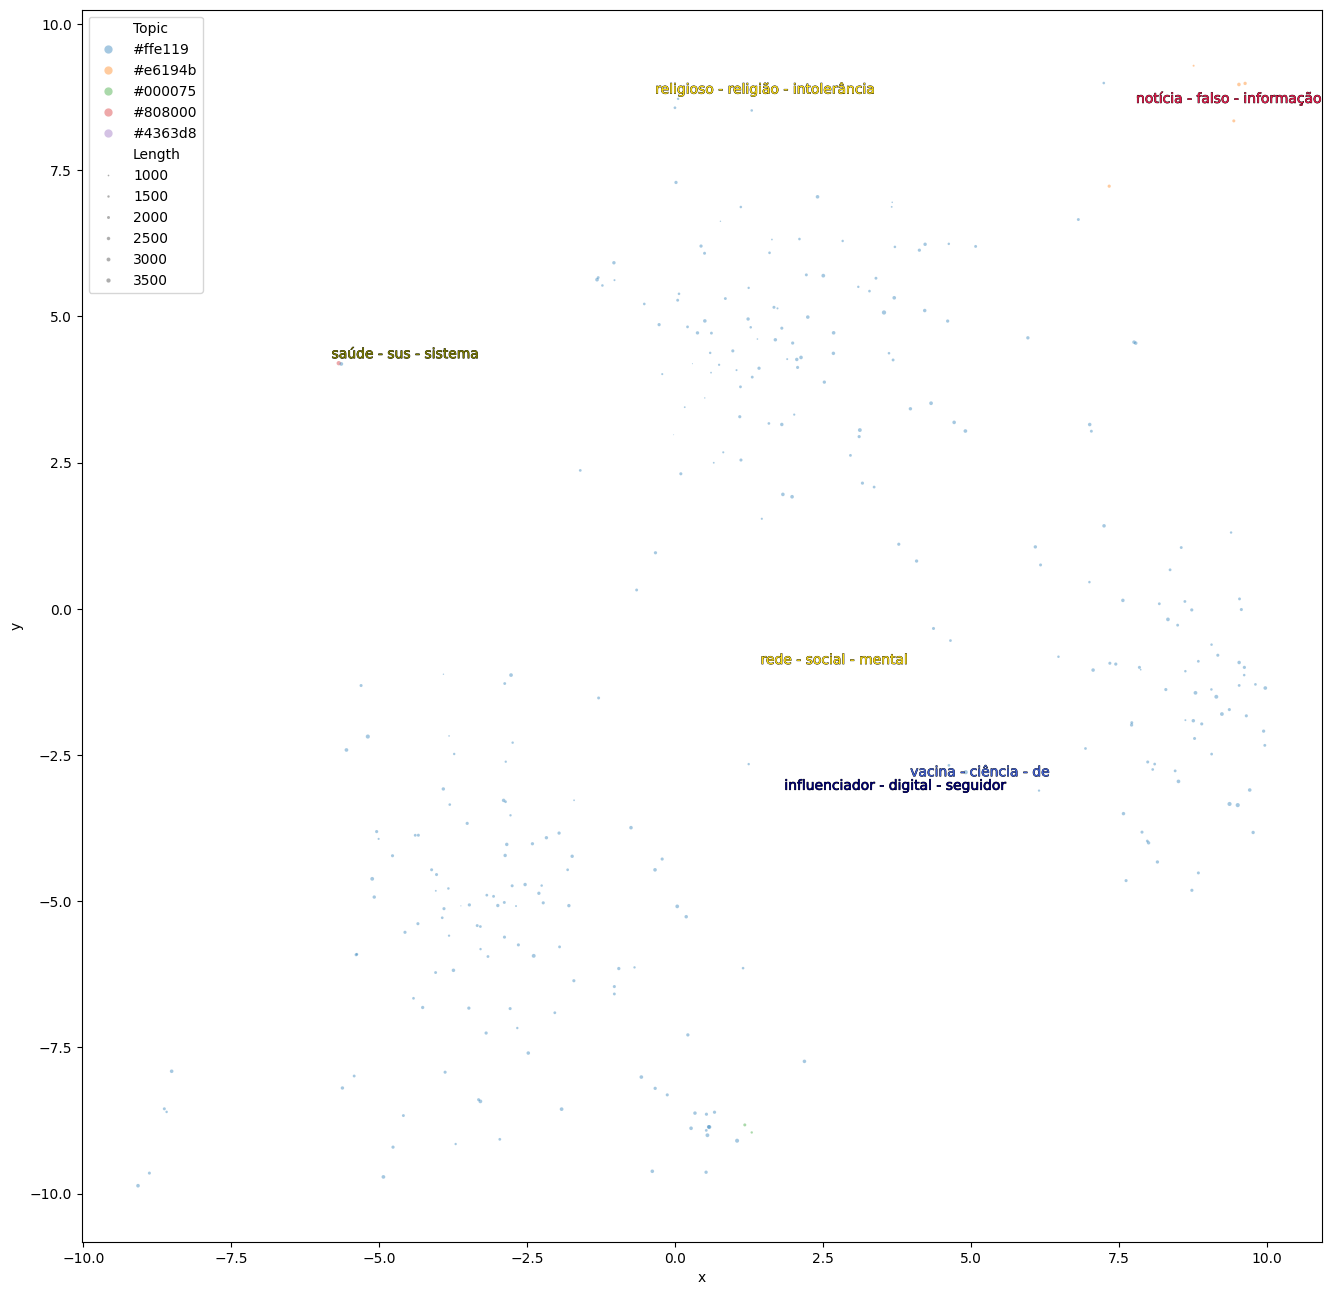

In [61]:
import seaborn as sns
from matplotlib import pyplot as plt
from adjustText import adjust_text
import matplotlib.patheffects as pe

fig = plt.figure(figsize=(16, 16))
sns.scatterplot(data=df, x='x', y='y', hue=df['Topic'].map(color_key), alpha=0.4, sizes=(0.4, 10), size="Length")

# Annotate top 50 topics
texts, xs, ys = [], [], []
for row in mean_df.iterrows():
  topic = row[1]["Topic"]
  name = " - ".join(list(zip(*topic_model.get_topic(int(topic))))[0][:3])

  if int(topic) <= 50:
    xs.append(row[1]["x"])
    ys.append(row[1]["y"])
    texts.append(plt.text(row[1]["x"], row[1]["y"], name, size=10, ha="center", color=color_key[str(int(topic))],
                          path_effects=[pe.withStroke(linewidth=0.5, foreground="black")]))

# Adjust annotations such that they do not overlap
adjust_text(texts, x=xs, y=ys, time_lim=1, force_text=(0.01, 0.02), force_static=(0.01, 0.02), force_pull=(0.5, 0.5))
plt.show()

Utils

In [68]:
from sklearn.metrics import silhouette_score
from hdbscan import HDBSCAN

def optimize_min_cluster_size(docs, embedding_model, reduced_embeddings, vectorizer_model=None,
                              range_min=10, range_max=100, step=20):
    if vectorizer_model is None:
        vectorizer_model = CountVectorizer()


    best_score = -1
    best_mcs = None
    silhouette_scores = {}

    for mcs in tqdm.tqdm(range(range_min, range_max + 1, step), desc="Optimizing min_cluster_size"):
        hdbscan_model = HDBSCAN(min_cluster_size=mcs, prediction_data=True, min_samples=5)

        topic_model = BERTopic(
            hdbscan_model=hdbscan_model,
            vectorizer_model=vectorizer_model,
            embedding_model=embedding_model,  # embeddings passed directly
            umap_model=Dimensionality(reduced_embeddings),
            calculate_probabilities=False,
            verbose=True
        )

        topics, _ = topic_model.fit_transform(docs, embeddings)

        # Remove outliers (topic = -1)
        indices = [i for i, t in enumerate(topics) if t != -1]
        if len(set([topics[i] for i in indices])) < 2:
            continue  # Silhouette score needs at least 2 clusters

        X = np.array([reduced_embeddings[i] for i in indices])
        labels = [topics[i] for i in indices]

        try:
            score = silhouette_score(X, labels)
            silhouette_scores[mcs] = score
            print(silhouette_scores)
            if score > best_score:
                best_score = score
                best_mcs = mcs
        except Exception:
            continue

    return best_mcs, silhouette_scores

In [69]:
best_mcs, scores = optimize_min_cluster_size(docs, sentence_model, reduced_embeddings, range_min=10, range_max=100, step=20)
print("Best min_cluster_size:", best_mcs)

Optimizing min_cluster_size:   0%|          | 0/5 [00:00<?, ?it/s]2026-04-24 19:01:34,438 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-24 19:01:34,438 - BERTopic - Dimensionality - Completed ✓
2026-04-24 19:01:34,441 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-24 19:01:34,755 - BERTopic - Cluster - Completed ✓
2026-04-24 19:01:34,761 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-04-24 19:01:36,556 - BERTopic - Representation - Completed ✓
Optimizing min_cluster_size:  20%|██        | 1/5 [00:04<00:19,  4.82s/it]2026-04-24 19:01:39,251 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-24 19:01:39,252 - BERTopic - Dimensionality - Completed ✓
2026-04-24 19:01:39,254 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-24 19:01:39,434 - BERTopic - Cluster - Completed ✓


{10: 0.8301228}


2026-04-24 19:01:39,439 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-04-24 19:01:40,948 - BERTopic - Representation - Completed ✓
Optimizing min_cluster_size:  40%|████      | 2/5 [00:08<00:13,  4.42s/it]2026-04-24 19:01:43,399 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-24 19:01:43,399 - BERTopic - Dimensionality - Completed ✓
2026-04-24 19:01:43,401 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-24 19:01:43,594 - BERTopic - Cluster - Completed ✓


{10: 0.8301228, 30: 0.82768285}


2026-04-24 19:01:43,599 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-04-24 19:01:45,118 - BERTopic - Representation - Completed ✓
Optimizing min_cluster_size:  60%|██████    | 3/5 [00:12<00:08,  4.20s/it]2026-04-24 19:01:47,324 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-24 19:01:47,324 - BERTopic - Dimensionality - Completed ✓
2026-04-24 19:01:47,326 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-24 19:01:47,511 - BERTopic - Cluster - Completed ✓


{10: 0.8301228, 30: 0.82768285, 50: 0.8222161}


2026-04-24 19:01:47,515 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-04-24 19:01:49,010 - BERTopic - Representation - Completed ✓
Optimizing min_cluster_size:  80%|████████  | 4/5 [00:16<00:04,  4.12s/it]2026-04-24 19:01:51,337 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-24 19:01:51,338 - BERTopic - Dimensionality - Completed ✓
2026-04-24 19:01:51,339 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-24 19:01:51,517 - BERTopic - Cluster - Completed ✓
2026-04-24 19:01:51,522 - BERTopic - Representation - Extracting topics from clusters using representation models.


{10: 0.8301228, 30: 0.82768285, 50: 0.8222161, 70: 0.82175416}


2026-04-24 19:01:53,032 - BERTopic - Representation - Completed ✓
Optimizing min_cluster_size: 100%|██████████| 5/5 [00:20<00:00,  4.13s/it]

{10: 0.8301228, 30: 0.82768285, 50: 0.8222161, 70: 0.82175416, 90: 0.8037606}
Best min_cluster_size: 10
